# Lab 02: Where Is the Star, and How Sure Are You Allowed to Be?

**ASTR 457, Fall 2026, posted Thu Sep 10, due Wed Sep 16 by Noon (fork → PR, as always)**

*Why this lab: centroiding is how every position in every catalog you'll ever use was measured, and the Cramér–Rao bound is the professional's sanity check (the best precision any measurement can claim) that tells you instantly when an error bar in a paper (or from an AI) is too good to be true.*

Every one of you has your own dataset: `data/<your netid>.csv`, with a single column `x`,
the arrival positions, in pixels, of individual photons on a 1-D detector window spanning
$[0, 64]$ px. Most of the photons come from a star whose image on the detector is a Moffat
profile centered at $x_0$, with shape parameters $\beta = 2.5$ and $r_0 = 4$ px (both known
to you). The rest are **background**: a fraction $f_{\rm bg}$ of the photons, spread uniformly
across the window. I know the true $x_0$ and $f_{\rm bg}$ for your dataset. You don't, and you
can't look them up, and your classmates' values are different from yours. (So are their photon
counts, so your Part 2 bound is yours alone.)

**How this is graded.** Not on whether your code runs, but on whether your answers are *right*
and your uncertainties are *honest*. Part of your grade comes from how close your reported
$x_0$ and $f_{\rm bg}$ are to your truth **in units of your own reported uncertainty**. Report
tiny error bars you can't back up and you will lose points even if your central value is close.
Report huge error bars to be safe and you'll lose points too. Calibration is the skill.
And this week there is a floor under "huge": your reported $\sigma_{x_0}$ may not exceed
**3× the Cramér–Rao bound** you compute in Part 2. An error bar bigger than that is not
caution, since it's an estimator you should have discarded.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The naive estimator (15%)

Load your photon list and plot a histogram of the arrival positions (choose your binning
deliberately, and you'll defend it). Then estimate the star's position the obvious way: the
**sample mean** of all the photon positions, with uncertainty $s/\sqrt{N}$ (the standard
error of the mean). Report $\hat{x}_0 \pm \sigma$.

Then answer, in a few sentences: is this estimator biased for *your* dataset, and why?
Which way does the bias pull, and what controls its size? (This estimator is *supposed* to
be biased. Understanding exactly how (and what the background has to do with it) is the
point.)

In [1]:
# Part 1: your work here
import numpy as np
import matplotlib.pyplot as plt
from astropy.stats import sigma_clip as sigma_clip
from scipy.optimize import minimize
from scipy.optimize._numdiff import approx_derivative
from scipy.special import gamma
from scipy.stats import t

In [2]:
x = np.genfromtxt('data_02.csv', delimiter=',')
x = x[~np.isnan(x)]
n = len(x)
print(n)

630


In [3]:
b = 2.5
ro = 4

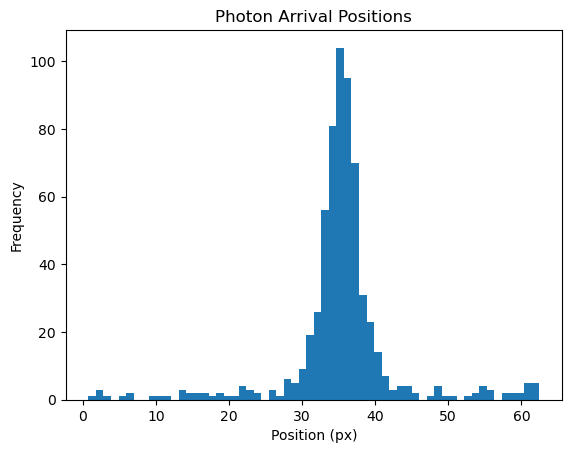

In [4]:
plt.hist(x, bins=60)
plt.title('Photon Arrival Positions'),plt.xlabel('Position (px)'), plt.ylabel('Frequency')
plt.show()

In [5]:
mean = np.sum(x)/n
sigma = mean/(np.sqrt(n))

print(f'Sample mean = {mean:.2f} +/- {sigma:.2f}')

Sample mean = 35.43 +/- 1.41


**ANSWER (a few sentences):**

This estimator appears to be bias for my dataset based on the histogram plot. It is pulled to the right by the photons in the upper pixel positions (40px+). These photons are from the background rather than the star itself based on how they sit away from the mean and main cluster of photons.

## Part 2: Estimators you can defend (40%)

Now do it properly. Estimate $x_0$ **three more ways** and compare:

1. **The median** of the photon positions. Robust, simple, but is it unbiased here, and
   what is its variance? (You may answer the variance question empirically in Part 3.)
2. **A sigma-clipped mean**: iteratively remove photons far from the current estimate,
   re-estimate, repeat until it converges. Be explicit about your clipping threshold and
   why you chose it.
3. **Maximum likelihood on the mixture model.** Each photon is background with probability
   $f_{\rm bg}$, or from the star otherwise, so the probability density for a single photon at
   position $x$ is

   $$p(x \mid x_0, f_{\rm bg}) \;=\; \frac{f_{\rm bg}}{64} \;+\; (1 - f_{\rm bg})\,
   \frac{\Gamma(\beta)}{r_0\sqrt{\pi}\,\Gamma(\beta - \tfrac{1}{2})}
   \left[1 + \left(\frac{x - x_0}{r_0}\right)^2\right]^{-\beta}$$

   with $\beta = 2.5$ and $r_0 = 4$ px. Maximize $\sum_i \ln p(x_i \mid x_0, f_{\rm bg})$ over
   both parameters (see Ivezić, Connolly, VanderPlas & Gray, §4.2, for the machinery; this
   is the same likelihood game with different symbols). Get uncertainties from the curvature
   of the log-likelihood at its peak (the observed information), and say so.

Then compute the **Cramér–Rao bound**: the smallest variance any unbiased estimator of $x_0$
can achieve given your $N$ photons. The per-photon Fisher information
$I(x_0) = \int \frac{1}{p}\left(\frac{\partial p}{\partial x_0}\right)^2 dx$ is yours to
evaluate (numerically over the window is fine) and the bound is
$\sigma_{x_0} \geq 1/\sqrt{N\,I}$. Treat both parameters as unknown: the honest bound comes
from inverting the $2\times 2$ Fisher matrix, not the $x_0$ term alone. How close does each
of your four estimators get?

(Two technicalities you may use without proof: photons landing outside the window were lost,
but for your $x_0$ the lost fraction is negligible, and checking that claim makes a fine
Part 3 sensitivity test. And for simulating: a 1-D Moffat with exponent $\beta$ is a
Student-$t$ distribution with $\nu = 2\beta - 1$ degrees of freedom, scaled by
$r_0/\sqrt{\nu}$.)

Commit to a **final answer**, one $x_0 \pm \sigma$ and $f_{\rm bg} \pm \sigma$ you'd put in
a paper, and justify the choice. State clearly how you estimated your uncertainties and why
you believe them. Remember the 3× rule from the header.

In [6]:
# Part 2: your work here
median = np.median(x)
var = (sigma**2) / n

In [7]:
print(f'Median = {median:.2f} +/- {var:.3f}')

Median = 35.41 +/- 0.003


In [8]:
#sigma clip
clip = sigma_clip(x, sigma = 3.0)
x_clip = x[~clip.mask]
n_clip = len(x_clip)
clipped_mean = np.sum(x_clip)/n_clip
clipped_sigma = clipped_mean/(np.sqrt(n_clip))

print(f'Clipped sample mean = {clipped_mean:.2f} +/- {clipped_sigma:.2f}')

Clipped sample mean = 35.39 +/- 1.51


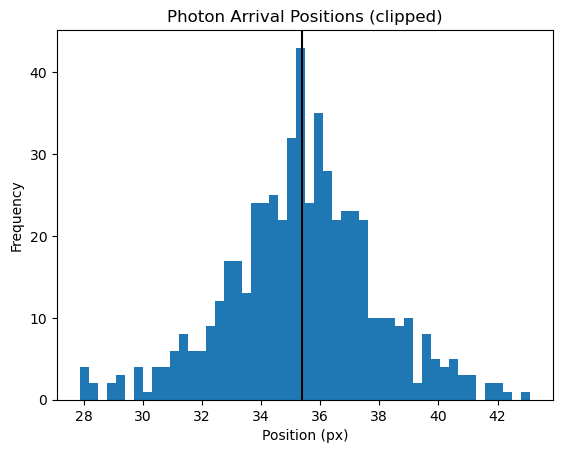

In [43]:
plt.hist(x_clip, bins = 50)
plt.axvline(clipped_mean, color='k')
plt.title('Photon Arrival Positions (clipped)'),plt.xlabel('Position (px)'), plt.ylabel('Frequency')
plt.show()

In [10]:
#max likelihood on mixture model
A = gamma(b) / (ro * np.sqrt(np.pi) * gamma(b - 0.5))

def pdf(x, x0, fbg):
    star = A * (1 + ((x - x0)/ro)**2)**(-b)
    bg = 1.0/64.0

    return fbg*bg + (1 - fbg)*star

lower, upper = np.percentile(x, [16, 84])
bound = (lower <= x) & (x <= upper)
fbg = len(x[~bound])/len(x)

def neg_loglike(par):
    x0, fbg = par
    p = pdf(x, x0, fbg)
    
    return -np.sum(np.log(p))

result = minimize(neg_loglike,[median, fbg], bounds=[(0,64),(1e-6,1-1e-6)])
xo, f_bg = result.x

In [11]:
#uncertainties
def Hm(theta):
    return approx_derivative(neg_loglike, theta)
    
H = approx_derivative(Hm, [xo,f_bg])
cov = np.linalg.inv(H)

xo_sig, fbg_sig = np.sqrt(np.diag(cov))

In [12]:
print(f"xo = {xo:.2f} +/- {xo_sig:.2f}")
print(f"f_bg = {f_bg:.2f} +/- {fbg_sig:.2f}")

xo = 35.43 +/- 0.11
f_bg = 0.15 +/- 0.02


In [13]:
#Cramér–Rao bound
def star_pdf(x, xo):
    return A * (1 + ((x - xo)/ro)**2)**(-b)

def dp_dfbg(x, xo):
    return 1.0/64.0 - star_pdf(x, xo)

def dp_dx0(x, xo, f_bg):
    u = 1 + ((x-xo)/ro)**2

    return (1-f_bg) * A * (2*b*(x-xo)/ro**2) * u**(-b-1)

grid = np.linspace(0, 64, 1000)
p = pdf(grid, xo, f_bg)
dx0 = dp_dx0(grid, xo, f_bg)
dfbg = dp_dfbg(grid, xo)

F11 = np.trapezoid((dx0*dx0)/p, grid)

F22 = np.trapezoid((dfbg*dfbg)/p, grid)

F12 = np.trapezoid((dx0*dfbg)/p, grid)

F = np.array([[F11, F12],[F12, F22]])
F2 = F * n

cov_crb = np.linalg.inv(F2)

sig_xo_crb, sig_fbg_crb = np.sqrt(np.diag(cov_crb))

print(f'Cramér–Rao bound for xo = {sig_xo_crb:.2f}')

Cramér–Rao bound for xo = 0.11


In [14]:
print(f'67% interval: {lower:.2f}, {upper:.2f}')

67% interval: 32.54, 38.39


In [15]:
print('All uncertainties')
print(f'3x CRB = {3 * sig_xo_crb:.2f}')
print(f'median = {var:.4f}')
print(f'sigma-clip = {clipped_sigma:.2f}')
print(f'mixture = {xo_sig:.2f}')

All uncertainties
3x CRB = 0.32
median = 0.0032
sigma-clip = 1.51
mixture = 0.11


In [16]:
print(f'median variance v. CRB = {var / sig_xo_crb}')
print(f'clipped mean uncertainty v. CRB = {clipped_sigma / sig_xo_crb}')
print(f'mixture uncertainty v. CRB = {xo_sig / sig_xo_crb}')

median variance v. CRB = 0.02984823158330514
clipped mean uncertainty v. CRB = 14.238268104083792
mixture uncertainty v. CRB = 0.9973413425048344


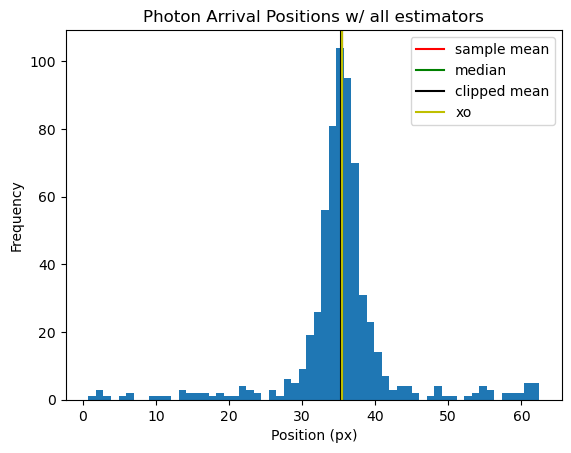

In [50]:
plt.hist(x, bins=60)
plt.title('Photon Arrival Positions w/ all estimators'),plt.xlabel('Position (px)'), plt.ylabel('Frequency')

plt.axvline(mean, color='r', label='sample mean')
plt.axvline(median, color='g', label='median')
plt.axvline(clipped_mean, color='k', label='clipped mean')
plt.axvline(xo, color='y', label='xo')

plt.legend()
plt.show()

**FINAL ANSWER:** $x_0 = $ 35.43 $\pm$ 0.11 px , $f_{\rm bg} = $ 0.15 $\pm$ 0.02 , Cramér–Rao bound $\sigma_{x_0}^{\rm CRB} = $ 0.11 px

**Justification and uncertainty method (a short paragraph):**

For my final answer I decided to report the calculated xo and fbg from the mixture model. To calculate the uncertainties of the values I took the inverse of the hessian matrix to get the covariance matrix. From there I took the square root of the diagonal entries similar lab 1. Looking at how the uncertainties compare to the CRB, the mixture model's uncertainty is the closest to 1. Which suggests it as the most unbias measurement of the three. The value being below 1 does suggest some bias towards the dataset in play, however the amount in this case is negligible. This uncertainty also does not exceed 3x the CRB.

## Part 3: The verification plan, written first and then executed (35%)

This is the headline of this lab. **Before you run anything below, write the plan** (3a).
A verification plan you invent after seeing the results is a rationalization.

**3a. The plan.** List the checks you will run to decide whether to trust your Part 2
numbers. At minimum, address:

1. **Closure**: simulate a dataset with a truth *you* choose (the Student-$t$ fact from
   Part 2 makes this easy) and confirm your estimator recovers it.
2. **Bias and efficiency**: Monte Carlo all four estimators on many simulated datasets at
   plausible parameters. Plot their bias and their variance against the Cramér–Rao bound.
   This is *the* figure of this lab.
3. **Coverage**: across your simulations, do your 68% intervals contain the truth 68% of
   the time?
4. **Sensitivity**: what happens to your $\hat{x}_0$ if $\beta$ or $r_0$ are slightly wrong,
   or if the lost-photon fraction isn't negligible after all?

For **each** check, state *in advance* what failure would look like. A check that cannot
fail is not a check.

**3b. The execution.** Run the plan. Report what each check found, including anything that
failed or surprised you. A failed check honestly reported and diagnosed is worth more than
a wall of green checkmarks.

**VERIFICATION PLAN (write this before running 3b):**

For verification, I will simulate a dataset with the calculated xo and fbg I decided to report in part 2. I will check if I am able to recover the the values. With multiple datasets I will calculate the percentage of intervals that contain the truth 68% of the time. Finally I will recalculate the maximum likelihood on the mixture model with adjusted $\beta$ and $r_0$ values to see how $\hat{x}_0$ is affected.

If I am unable to recover my chosen truth from part 2 with the simulated data, that would be failure. If my simulated intervals do not contain the truth 68% of the time that suggests failure of my errors. $\hat{x}_0$ being highly sensitive to $\beta$ and $r_0$ would suggest the calculations of the estimators may be less reliable than expected if the values are not true.

In [17]:
# Part 3b: execute the plan here
def simulate_dataset(n=630, xo=35.43, fbg=0.15, b=2.5, ro=4):
    nu = 2*b - 1
    scale = ro / np.sqrt(nu)
    nbg = np.random.binomial(n, fbg)
    nstar = n - nbg
    x_star = xo + scale*t.rvs(df=nu,size=nstar)
    x_bg = np.random.uniform(0,64,size=nbg)
    x = np.concatenate([x_star, x_bg])
    return x

In [18]:
x_sim = simulate_dataset()
median_sim = np.median(x_sim)

A = gamma(b) / (ro * np.sqrt(np.pi) * gamma(b - 0.5))

def pdf(x, x0, fbg):
    star = A * (1 + ((x - x0)/ro)**2)**(-b)
    bg = 1.0/64.0

    return fbg*bg + (1 - fbg)*star

lower, upper = np.percentile(x_sim, [16, 84])
bound = (lower <= x_sim) & (x_sim <= upper)
fbg = len(x_sim[~bound])/len(x_sim)

def neg_loglike(par):
    x0, fbg = par
    p = pdf(x, x0, fbg)
    
    return -np.sum(np.log(p))

result = minimize(neg_loglike,[median_sim, fbg], bounds=[(0,64),(1e-6,1-1e-6)])
xo_sim, f_bg_sim = result.x

H_sim = approx_derivative(Hm, [xo,f_bg])
cov_sim = np.linalg.inv(H)

xo_sig_sim, fbg_sig_sim = np.sqrt(np.diag(cov))

print(f"Recovered xo = {xo_sim:.2f} +/- {xo_sig_sim:.2f}")
print(f"Recovered f_bg = {f_bg_sim:.2f} +/- {fbg_sig_sim:.2f}")

Recovered xo = 35.43 +/- 0.11
Recovered f_bg = 0.15 +/- 0.02


In [25]:
nsim = 1000

inside = []
xo_vals = []

for i in range(nsim):
    sim = simulate_dataset()
    n = len(sim)
    
    median = np.median(sim)
    
    lower, upper = np.percentile(sim, [16, 84])
    bound = (lower <= sim) & (sim <= upper)
    fbg = len(sim[~bound])/len(sim)

    result = minimize(neg_loglike,[median,fbg],bounds=[(0,64),(1e-6,1-1e-6)])

    xo_est, f_bg_est = result.x

    H_sim = approx_derivative(Hm, [xo,f_bg])
    cov_sim = np.linalg.inv(H)

    xo_sig_est, fbg_sig_est = np.sqrt(np.diag(cov))

    contains_truth = (xo >= xo_est - xo_sig_est) & (xo <= xo_est + xo_sig_est)

    xo_vals.append(xo_est)
    inside.append(contains_truth)

In [22]:
coverage = np.mean(inside)
print(coverage)

1.0


In [23]:
x_sim = simulate_dataset(b=1.5,ro=3)
median_sim = np.median(x_sim)

A = gamma(b) / (ro * np.sqrt(np.pi) * gamma(b - 0.5))

def pdf(x, x0, fbg):
    star = A * (1 + ((x - x0)/ro)**2)**(-b)
    bg = 1.0/64.0

    return fbg*bg + (1 - fbg)*star

lower, upper = np.percentile(x_sim, [16, 84])
bound = (lower <= x_sim) & (x_sim <= upper)
fbg = len(x_sim[~bound])/len(x_sim)

def neg_loglike(par):
    x0, fbg = par
    p = pdf(x, x0, fbg)
    
    return -np.sum(np.log(p))

result = minimize(neg_loglike,[median_sim, fbg], bounds=[(0,64),(1e-6,1-1e-6)])
xo_sim, f_bg_sim = result.x

H_sim = approx_derivative(Hm, [xo,f_bg])
cov_sim = np.linalg.inv(H)

xo_sig_sim, fbg_sig_sim = np.sqrt(np.diag(cov))

print('xo and f_bg with beta = 1.5 and ro = 3')
print(f"xo = {xo_sim:.10f} +/- {xo_sig_sim:.4f}")
print(f"f_bg = {f_bg_sim:.10f} +/- {fbg_sig_sim:.4f}")

xo and f_bg with beta = 1.5 and ro = 3
xo = 35.4313695096 +/- 0.1057
f_bg = 0.1503356456 +/- 0.0173


In [24]:
x_sim = simulate_dataset(b=3.5,ro=5)
median_sim = np.median(x_sim)

A = gamma(b) / (ro * np.sqrt(np.pi) * gamma(b - 0.5))

def pdf(x, x0, fbg):
    star = A * (1 + ((x - x0)/ro)**2)**(-b)
    bg = 1.0/64.0

    return fbg*bg + (1 - fbg)*star

lower, upper = np.percentile(x_sim, [16, 84])
bound = (lower <= x_sim) & (x_sim <= upper)
fbg = len(x_sim[~bound])/len(x_sim)

def neg_loglike(par):
    x0, fbg = par
    p = pdf(x, x0, fbg)
    
    return -np.sum(np.log(p))

result = minimize(neg_loglike,[median_sim, fbg], bounds=[(0,64),(1e-6,1-1e-6)])
xo_sim, f_bg_sim = result.x

H_sim = approx_derivative(Hm, [xo,f_bg])
cov_sim = np.linalg.inv(H)

xo_sig_sim, fbg_sig_sim = np.sqrt(np.diag(cov))

print('xo and f_bg with beta = 1.5 and ro = 3')
print(f"xo = {xo_sim:.10f} +/- {xo_sig_sim:.4f}")
print(f"f_bg = {f_bg_sim:.10f} +/- {fbg_sig_sim:.4f}")

xo and f_bg with beta = 1.5 and ro = 3
xo = 35.4313706385 +/- 0.1057
f_bg = 0.1503356446 +/- 0.0173


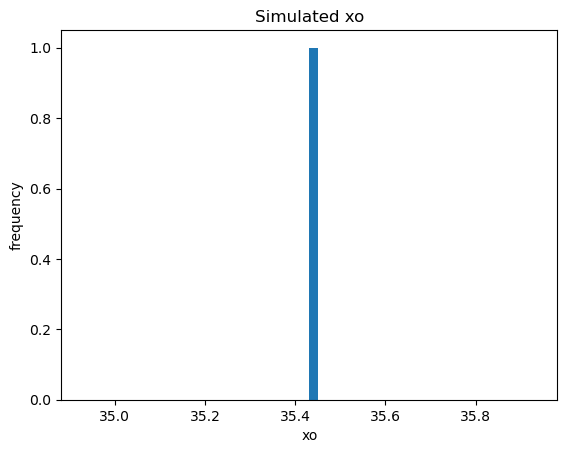

In [63]:
plt.hist(xo_vals[1], bins=50)
plt.title("Simulated xo"), plt.xlabel("xo"), plt.ylabel("frequency")
plt.show()

**WHAT THE CHECKS FOUND:**

With my checks I was able to easily recover the truth that I reported in part 2. However the results of my other checks suggest that this may not be a reliable metric. Particularly the interval check, which reported that my intervals contain the truth 100% of the time. I was surprised to see this as I was fairly confident in the mixture model's performance. However in combination with the nonexistent variation seen between each simulated xo and fbg it does make sense. Even when there is variation of the $\beta$ and $r_0$ values. There is never a point my values get even close to straying away from the interval [32.54, 38.39].

## Part 4: AI-use appendix (10%)

**AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
is fine if true. (Your verification plan lives in Part 3 this week; it earned a
promotion. If an AI wrote any of it, that belongs here too.)

**AI-USE APPENDIX:**

For this lab I used Copilot to help with the calculation of the maximum likelihood of the mixture model and the Cramér–Rao bound in part 2. I asked for it to explain how I could approach both with python. The ratio comparison I did for my values was suggested by Copilot as well. I compared the results it gave to the mixture model methods discussed in lecture that was utilized in lab 01. Whenever the model suggested something unfamiliar I asked follow up questions, sources for further reading, and searched myself through Google.

For part 3, I once again asked for coding help in the approach of my verification plan. I referenced Copilot's code suggestions for several steps in the verification process while adjusting to fit my needs. Including how to simulate data, run the simulation multiple times, calculate if the 68% intervals contain the truth 68% of the time. 